In [ ]:
# Standard library
import pickle
import random

# Scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# OpenMM
import openmm
import openmm.app as app
from openmm import unit

# OpenFF
from openff.toolkit import ForceField, Molecule, Topology
from openff.interchange import Interchange

# RDKit
from rdkit import Chem
from rdkit.Chem import Draw

# ASE
from ase.io import read

# PySAGES
import pysages
from pysages.approxfun import compute_mesh
from pysages.backends.openmm import get_cache
from pysages.colvars import DihedralAngle
from pysages.colvars.core import CollectiveVariable, multicomponent
from pysages.grids import Grid
from pysages.methods import Metadynamics, MetaDLogger

# QUESTS
from quests.descriptor import get_descriptors
from quests.entropy import entropy, delta_entropy

# Local
from utils import *

## Reference setup

In [3]:
refer = read('unbiased/300K_nvt.pdb', index=':')
random.seed(42)
random.shuffle(refer)
# sample 100 frames as the reference dataset {X}
refer = random.sample(refer, 100)

## Setup molecule

/home/xiangrui/miniconda3/envs/sim/lib/python3.12/site-packages/openff/amber_ff_ports/amber_ff_ports.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


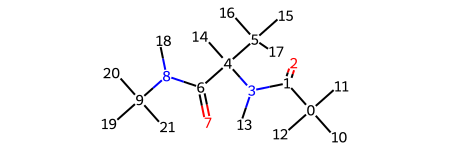

In [4]:
# ala2 smiles string and force field file
alanine_dipeptide = 'CC(=O)NC(C)C(=O)NC'
force_field = 'openff-2.0.0.offxml'

# create an molecule object from the smiles string
ala = Molecule.from_smiles(alanine_dipeptide, allow_undefined_stereo=True)
rdkit_mol = ala.to_rdkit()
for atom in rdkit_mol.GetAtoms():
    atom.SetProp('atomLabel', str(atom.GetIdx()))

# generate conformer and attach a force field to the molecule
ala.generate_conformers(n_conformers=1)
top = Topology.from_molecules(ala)
ff = ForceField(force_field)
inter = Interchange.from_smirnoff(force_field=ff, topology=top)

top_pos = top.get_positions() * unit.nanometer

# draw the molecule with index labels for each atom
rdkit_mol

## Define collective variable

In [5]:
# embede reference configurations into the descriptor space
Mi = []
for atoms in refer:
    positions = atoms.get_positions() * unit.angstrom
    mi = get_descriptor(positions.value_in_unit(unit.nanometer))
    Mi.append(mi)
Mi = jnp.vstack(Mi)
bandwidth = 1

# define the collective variable, which is the delta entropy between the current configuration embedding Y and the reference dataset {X}
def collective_variable(rs):
    M = get_descriptor(rs)
    dH = delta_entropy(M, Mi, bandwidth)
    return dH

# pysages requirements for high-dimensional CVs
@multicomponent
class EntropyCV(CollectiveVariable):
    @property
    def function(self): 
        return lambda rs: collective_variable(rs)

# customized logger to save the forces and bias during the metadynamics simulation
class CustomMetaDLogger(MetaDLogger):
    def __init__(self, hills_file, forces_file, log_period):
        super().__init__(hills_file, log_period)
        self.forces_file = forces_file

    def save_forces(self, forces, bias):
        with open(f'{self.forces_file}.frc', "a+", encoding="utf8") as f:
            f.write(str(self.counter) + "\t")
            f.write("\t".join(map(str, forces.flatten())) + "\n")
            print(forces[0])
        with open(f'{self.forces_file}.bias', "a+", encoding="utf8") as f:
            f.write(str(self.counter) + "\t")
            f.write("\t".join(map(str, bias.flatten())) + "\n")

    def __call__(self, snapshot, state, timestep):
        """
        Implements the logging itself. Interface as expected for Callbacks.
        """
        if self.counter >= self.log_period and self.counter % self.log_period == 0:
            idx = state.idx - 1 if state.idx > 0 else 0
            self.save_hills(state.centers[idx], state.sigmas, state.heights[idx])
            # self.save_forces(snapshot.forces, state.bias)

        self.counter += 1   

## Parameter setup

In [6]:
# cvs = [DihedralAngle([1,3,4,6]), DihedralAngle([3,4,6,8])]
cvs = [EntropyCV(np.arange(len(ala.atoms)))]

# parameters
pi = np.pi                                 
height = 1.2 # kj/mol
sigma = [1] * len(cvs)
deltaT = 5000
stride = 100
timesteps = int(1e7)
ngauss = timesteps // stride
prefix = 'test/results_mask/'
output_stride = int(200)

if prefix == 'results_unbiased/':
    file_name = 'unbiased'
elif prefix == 'results_dynamic_deltaH/':
    track_freq = 200
    file_name = f'{height}_{sigma[0]}_{bandwidth}_{stride}_{deltaT}_{track_freq}'
else:
    file_name = f'{height}_{sigma[0]}_{bandwidth}_{stride}_{deltaT}'

kB = unit.BOLTZMANN_CONSTANT_kB * unit.AVOGADRO_CONSTANT_NA
kB = kB.value_in_unit(unit.kilojoules_per_mole / unit.kelvin)

method = Metadynamics(cvs=cvs, height=height, sigma=sigma, stride=stride, ngaussians=ngauss, deltaT=deltaT, kB=kB)
# callback = MetaDLogger(f'{prefix}{file_name}.dat', output_stride)
callback = CustomMetaDLogger(f'{prefix}{file_name}.dat', f'{prefix}{file_name}', output_stride)

## OpenMM simulation setup

In [ ]:
def generate_simualtion(inter=inter, file_name=prefix+file_name, output_stride=output_stride):
    # log stride
    trj_freq = output_stride
    data_freq = output_stride

    # Integrator parameters
    time_step = 1 * unit.femtoseconds
    temperature = 300 * unit.kelvin
    friction = 10 / unit.picoseconds

    # set up the simulation
    integrator = openmm.LangevinIntegrator(temperature, friction, time_step)
    simulation = inter.to_openmm_simulation(integrator=integrator)
    simulation.context.setVelocitiesToTemperature(temperature)

    pdb_reporter = app.PDBReporter(f"{file_name}.pdb", trj_freq)
    state_data_reporter = app.StateDataReporter(
        f"{file_name}.csv",
        data_freq,
        step=True,
        potentialEnergy=True,
        kineticEnergy=True,
        temperature=True,
    )
    simulation.reporters.append(pdb_reporter)
    simulation.reporters.append(state_data_reporter)

    return simulation

## Run biased simulation

In [ ]:
run_results = pysages.run(method, generate_simualtion, timesteps, callback)